# CS4082 – Lab 2: Machine Learning with Scikit-Learn
## Final Submission Version (With Visualizations)

Student Name: UMAR AYYASH

Student ID: S22107722


## Part 1 – Verify Installation

In [1]:
import sklearn
print(f"scikit-learn version: {sklearn.__version__}")
import numpy as np
import matplotlib.pyplot as plt
print("All libraries loaded successfully!")


scikit-learn version: 1.6.1
All libraries loaded successfully!


## Part 2 – Load and Explore Iris Dataset (Task 1)

In [2]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

print('Feature names:', iris.feature_names)
print('Target names:', iris.target_names)
print('Data shape:', X.shape)

# Task 1: first 10 rows of X and y side by side
print('\nFirst 10 rows (X) and labels (y):')
for i in range(10):
    print(f"{i:02d}: X={X[i]}  y={y[i]} ({iris.target_names[y[i]]})")

# Task 1: class distribution
print('\nClass distribution:', np.unique(y, return_counts=True))


Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Data shape: (150, 4)

First 10 rows (X) and labels (y):
00: X=[5.1 3.5 1.4 0.2]  y=0 (setosa)
01: X=[4.9 3.  1.4 0.2]  y=0 (setosa)
02: X=[4.7 3.2 1.3 0.2]  y=0 (setosa)
03: X=[4.6 3.1 1.5 0.2]  y=0 (setosa)
04: X=[5.  3.6 1.4 0.2]  y=0 (setosa)
05: X=[5.4 3.9 1.7 0.4]  y=0 (setosa)
06: X=[4.6 3.4 1.4 0.3]  y=0 (setosa)
07: X=[5.  3.4 1.5 0.2]  y=0 (setosa)
08: X=[4.4 2.9 1.4 0.2]  y=0 (setosa)
09: X=[4.9 3.1 1.5 0.1]  y=0 (setosa)

Class distribution: (array([0, 1, 2]), array([50, 50, 50]))


### Visualization – Sepal Length vs Sepal Width

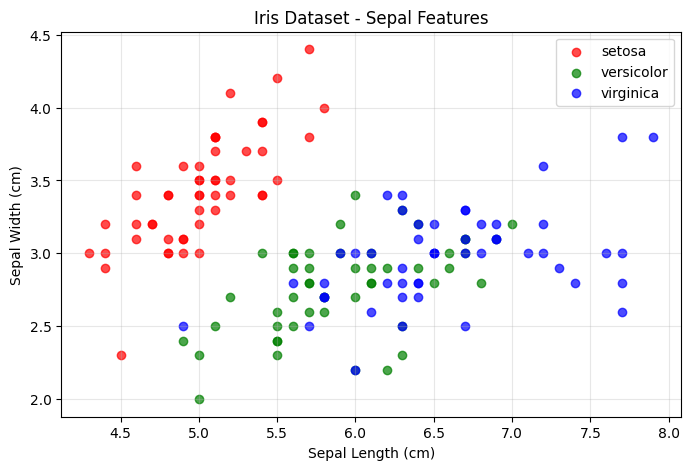

In [3]:
plt.figure(figsize=(8,5))
colors = ['red', 'green', 'blue']
for i, name in enumerate(iris.target_names):
    mask = (y == i)
    plt.scatter(X[mask, 0], X[mask, 1], color=colors[i], label=name, alpha=0.7)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Iris Dataset - Sepal Features')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Visualization – Petal Length vs Petal Width (Task 1)

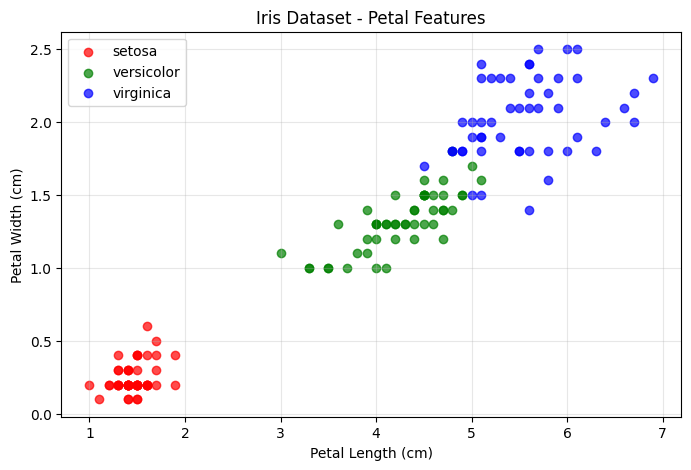

In [4]:
plt.figure(figsize=(8,5))
colors = ['red', 'green', 'blue']
for i, name in enumerate(iris.target_names):
    mask = (y == i)
    plt.scatter(X[mask, 2], X[mask, 3], color=colors[i], label=name, alpha=0.7)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris Dataset - Petal Features')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Part 3 – Train/Test Split (Task 2)

In [5]:
from sklearn.model_selection import train_test_split

# With stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('With stratify=y')
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train distribution:', np.unique(y_train, return_counts=True))
print('y_test distribution :', np.unique(y_test, return_counts=True))

# Without stratify (compare)
X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('\nWithout stratify')
print('y_train distribution:', np.unique(y_train_ns, return_counts=True))
print('y_test distribution :', np.unique(y_test_ns, return_counts=True))


With stratify=y
X_train shape: (120, 4)
X_test shape: (30, 4)
y_train distribution: (array([0, 1, 2]), array([40, 40, 40]))
y_test distribution : (array([0, 1, 2]), array([10, 10, 10]))

Without stratify
y_train distribution: (array([0, 1, 2]), array([40, 41, 39]))
y_test distribution : (array([0, 1, 2]), array([10,  9, 11]))


## Part 4 – Train Models (Task 3)

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

print('Decision Tree predictions (first 10):', dt_predictions[:10])
print('Actual labels (first 10):', y_test[:10])

# KNN (k=5)
knn_model_5 = KNeighborsClassifier(n_neighbors=5)
knn_model_5.fit(X_train, y_train)
knn_predictions_5 = knn_model_5.predict(X_test)
print('\nKNN (k=5) predictions (first 10):', knn_predictions_5[:10])

# KNN (k=3)
knn_model_3 = KNeighborsClassifier(n_neighbors=3)
knn_model_3.fit(X_train, y_train)
knn_predictions_3 = knn_model_3.predict(X_test)
print('KNN (k=3) predictions (first 10):', knn_predictions_3[:10])

# KNN (k=10)
knn_model_10 = KNeighborsClassifier(n_neighbors=10)
knn_model_10.fit(X_train, y_train)
knn_predictions_10 = knn_model_10.predict(X_test)
print('KNN (k=10) predictions (first 10):', knn_predictions_10[:10])


Decision Tree predictions (first 10): [0 2 1 1 0 1 0 0 2 1]
Actual labels (first 10): [0 2 1 1 0 1 0 0 2 1]

KNN (k=5) predictions (first 10): [0 2 1 1 0 1 0 0 2 1]
KNN (k=3) predictions (first 10): [0 2 1 1 0 1 0 0 2 1]
KNN (k=10) predictions (first 10): [0 2 1 1 0 1 0 0 2 1]


## Part 5 – Model Evaluation + Confusion Matrix (Task 4)

Decision Tree Accuracy: 93.33%
KNN Accuracy: 100.00%

=== Decision Tree Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

=== KNN Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



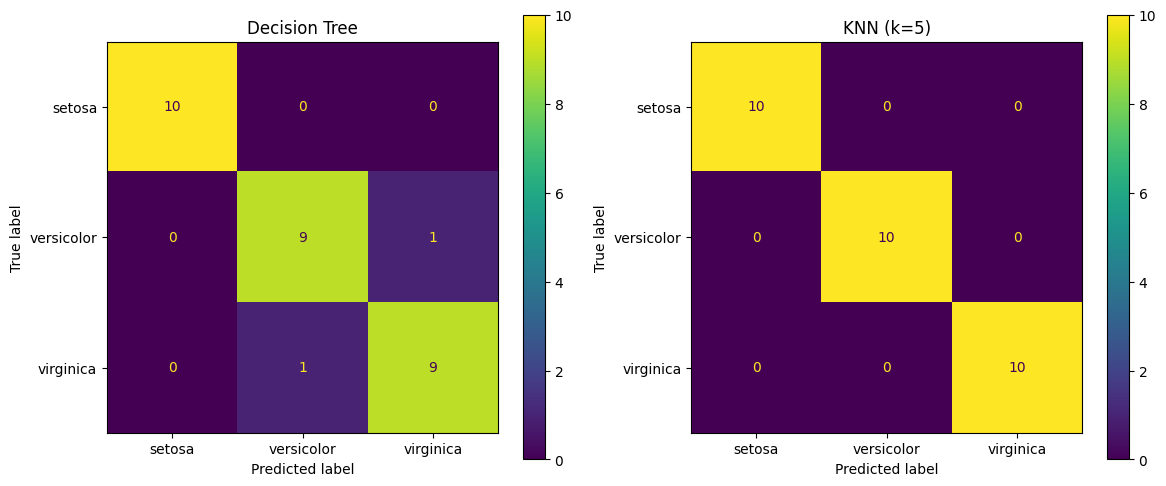

In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Use Decision Tree and KNN(k=5) for main comparison
knn_predictions = knn_predictions_5
knn_model = knn_model_5

dt_accuracy = accuracy_score(y_test, dt_predictions)
knn_accuracy = accuracy_score(y_test, knn_predictions)

print(f'Decision Tree Accuracy: {dt_accuracy:.2%}')
print(f'KNN Accuracy: {knn_accuracy:.2%}')

print('\n=== Decision Tree Report ===')
print(classification_report(y_test, dt_predictions, target_names=iris.target_names))

print('=== KNN Report ===')
print(classification_report(y_test, knn_predictions, target_names=iris.target_names))

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_dt = confusion_matrix(y_test, dt_predictions)
ConfusionMatrixDisplay(cm_dt, display_labels=iris.target_names).plot(ax=axes[0])
axes[0].set_title('Decision Tree')

cm_knn = confusion_matrix(y_test, knn_predictions)
ConfusionMatrixDisplay(cm_knn, display_labels=iris.target_names).plot(ax=axes[1])
axes[1].set_title('KNN (k=5)')

plt.tight_layout()
plt.show()


## Part 6 – Predict New Samples (Task 5)

In [8]:
new_flowers = np.array([
    [6.7, 3.0, 5.2, 2.3],
    [5.8, 2.7, 4.1, 1.0],
    [4.9, 3.1, 1.5, 0.1]
])

dt_preds = dt_model.predict(new_flowers)
knn_preds = knn_model.predict(new_flowers)

for i, flower in enumerate(new_flowers, start=1):
    print(f'Flower {i}: {flower}')
    print('  Decision Tree:', iris.target_names[dt_preds[i-1]])
    print('  KNN:', iris.target_names[knn_preds[i-1]])


Flower 1: [6.7 3.  5.2 2.3]
  Decision Tree: virginica
  KNN: virginica
Flower 2: [5.8 2.7 4.1 1. ]
  Decision Tree: versicolor
  KNN: versicolor
Flower 3: [4.9 3.1 1.5 0.1]
  Decision Tree: setosa
  KNN: setosa


## Part 7 – Working with CSV Data (Task 6)

In [9]:
import pandas as pd

# Create sample CSV
np.random.seed(42)
n = 100
data = {
    'study_hours': np.round(np.random.uniform(1, 10, n), 1),
    'attendance_pct': np.round(np.random.uniform(40, 100, n), 1),
    'assignments': np.random.randint(3, 10, n),
    'passed': np.random.choice([0, 1], n, p=[0.35, 0.65])
}
df = pd.DataFrame(data)
df.to_csv('students.csv', index=False)

# Load CSV
df = pd.read_csv('students.csv')
print('Shape:', df.shape)
print('\nColumn types:\n', df.dtypes)
print('\nInfo:')
df.info()
print('\nDescribe:\n', df.describe())

# Prepare X, y
X_csv = df[['study_hours', 'attendance_pct', 'assignments']].values
y_csv = df['passed'].values
print('\nClass counts:', np.unique(y_csv, return_counts=True))

# Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_csv, y_csv, test_size=0.2, random_state=42, stratify=y_csv
)

# Decision Tree
dt_csv = DecisionTreeClassifier(random_state=42)
dt_csv.fit(X_train_c, y_train_c)
pred_dt_csv = dt_csv.predict(X_test_c)
acc_dt_csv = accuracy_score(y_test_c, pred_dt_csv)

# KNN
knn_csv = KNeighborsClassifier(n_neighbors=5)
knn_csv.fit(X_train_c, y_train_c)
pred_knn_csv = knn_csv.predict(X_test_c)
acc_knn_csv = accuracy_score(y_test_c, pred_knn_csv)

print('\nCSV Decision Tree Accuracy:', f'{acc_dt_csv:.2%}')
print('CSV KNN Accuracy:', f'{acc_knn_csv:.2%}')


Shape: (100, 4)

Column types:
 study_hours       float64
attendance_pct    float64
assignments         int64
passed              int64
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   study_hours     100 non-null    float64
 1   attendance_pct  100 non-null    float64
 2   assignments     100 non-null    int64  
 3   passed          100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB

Describe:
        study_hours  attendance_pct  assignments      passed
count   100.000000      100.000000   100.000000  100.000000
mean      5.233000       69.871000     6.000000    0.690000
std       2.681438       17.583476     1.959179    0.464823
min       1.000000       40.400000     3.000000    0.000000
25%       2.775000       54.500000     4.750000    0.000000
50%       5.150000       70.350000     6.000000 

## Final Comparison (Required Written Reflection)

In this lab, I trained and evaluated a Decision Tree and a KNN classifier on the Iris dataset. Using the same train/test split, KNN (k=5) achieved higher accuracy than the Decision Tree in my run, which suggests it generalized better on this small dataset. KNN makes predictions based on nearby training points, so it can capture smooth class boundaries, while the Decision Tree learns explicit if-then rules. The Decision Tree is easier to interpret because its decisions can be explained as a set of rules, but it may overfit if the tree becomes too complex. KNN can be slower at prediction time on large datasets because it must compute distances to many points. For this task, I would choose KNN because it achieved the best accuracy, but I would choose a Decision Tree if interpretability and fast prediction were more important.
